# Business Understanding

Permasalahan:
Banyak individu mengalami stres tetapi tidak menyadari tingkat stresnya.

Tujuan:
Membangun sistem prediksi tingkat stres berdasarkan
questionnaire PSS dan lifestyle data.

Target:
Mengklasifikasikan:
- Low Stress
- Medium Stress
- High Stress

# Import Library

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

pd.set_option('display.max_columns', None)

# Data Gathering

In [6]:
sleep_df = pd.read_csv(
    "/content/Sleep_health_and_lifestyle_dataset.csv"
)

student_df = pd.read_csv(
    "/content/student_stress_sleep_screen.csv"
)

print("""
DATA SOURCES
1. Sleep Health and Lifestyle Dataset
2. Student Stress Sleep Screen Dataset
""")


DATA SOURCES
1. Sleep Health and Lifestyle Dataset
2. Student Stress Sleep Screen Dataset



Data berasal dari 2 dataset, yaitu:
1. Sleep Health and Lifestyle Dataset
2. Student Stress Sleep Screen Dataset


# Clean Column Name

In [7]:
sleep_df.columns = (
    sleep_df.columns
    .str.lower()
    .str.replace(" ", "_")
)

student_df.columns = (
    student_df.columns
    .str.lower()
    .str.replace(" ", "_")
)

Kode tersebut digunakan untuk membersihkan dan menyeragamkan nama kolom pada DataFrame `sleep_df` dan `student_df`. Proses yang dilakukan adalah mengubah seluruh nama kolom menjadi huruf kecil (lowercase) serta mengganti spasi dengan tanda underscore (`_`). Tujuannya agar nama kolom lebih konsisten, mudah dibaca, dan memudahkan proses analisis maupun pemanggilan kolom dalam Python/Pandas tanpa harus berurusan dengan perbedaan huruf kapital atau spasi pada nama kolom.


# Assesing Data

In [8]:
print("""
SLEEP DATASET INFO
""")

print(sleep_df.info())

print("""
STUDENT DATASET INFO
""")

print(student_df.info())


SLEEP DATASET INFO

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   person_id                374 non-null    int64  
 1   gender                   374 non-null    object 
 2   age                      374 non-null    int64  
 3   occupation               374 non-null    object 
 4   sleep_duration           374 non-null    float64
 5   quality_of_sleep         374 non-null    int64  
 6   physical_activity_level  374 non-null    int64  
 7   stress_level             374 non-null    int64  
 8   bmi_category             374 non-null    object 
 9   blood_pressure           374 non-null    object 
 10  heart_rate               374 non-null    int64  
 11  daily_steps              374 non-null    int64  
 12  sleep_disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB
N

Berdasarkan informasi struktur data, **Sleep Dataset** terdiri dari 374 observasi dan 13 variabel, dengan tipe data yang beragam yaitu 7 variabel numerik bertipe `int64`, 1 variabel numerik bertipe `float64`, dan 5 variabel kategorikal bertipe `object`. Seluruh variabel memiliki data lengkap kecuali `sleep_disorder` yang hanya memiliki 155 nilai non-null, menunjukkan adanya missing value pada variabel tersebut. Sementara itu, **Student Dataset** terdiri dari 500 observasi dan 10 variabel, yang mencakup 2 variabel bertipe `int64`, 3 variabel bertipe `float64`, dan 5 variabel kategorikal bertipe `object`. Semua variabel pada dataset ini memiliki 500 nilai non-null, sehingga tidak terdapat missing value. Secara keseluruhan, kedua dataset memiliki struktur data yang baik dan siap untuk dianalisis, dengan perhatian khusus pada penanganan missing value pada variabel `sleep_disorder` di Sleep Dataset.


## Missing Values dan Duplicated Data

In [9]:
print("""
MISSING VALUE - SLEEP DATASET
""")

print(sleep_df.isnull().sum())

print("""
MISSING VALUE - STUDENT DATASET
""")

print(student_df.isnull().sum())

print("""
DUPLICATE DATA
""")
print("Sleep Duplicate :", sleep_df.duplicated().sum())
print("Student Duplicate :", student_df.duplicated().sum())


MISSING VALUE - SLEEP DATASET

person_id                    0
gender                       0
age                          0
occupation                   0
sleep_duration               0
quality_of_sleep             0
physical_activity_level      0
stress_level                 0
bmi_category                 0
blood_pressure               0
heart_rate                   0
daily_steps                  0
sleep_disorder             219
dtype: int64

MISSING VALUE - STUDENT DATASET

student_id           0
age                  0
gender               0
sleep_hours          0
screen_time_hours    0
stress_level         0
study_hours          0
physical_activity    0
caffeine_intake      0
academic_pressure    0
dtype: int64

DUPLICATE DATA

Sleep Duplicate : 0
Student Duplicate : 0


Berdasarkan hasil pengecekan kualitas data, pada **Sleep Dataset** ditemukan missing value hanya pada variabel `sleep_disorder` sebanyak **219 data**, sedangkan seluruh variabel lainnya tidak memiliki nilai yang hilang. Sementara itu, **Student Dataset** tidak memiliki missing value pada seluruh variabel yang tersedia. Selain itu, hasil pemeriksaan duplikasi menunjukkan bahwa kedua dataset tidak memiliki data duplikat (`0 duplicate`), sehingga kualitas data secara umum cukup baik dan hanya memerlukan penanganan khusus pada missing value di variabel `sleep_disorder` sebelum dilakukan analisis lebih lanjut. Namun, karena variabel itu tidak kami gunakan pada variabel final dataset yang merujuk pada Perceived Stress Scale (PSS) jadi tidak tindaklanjuti.

# Cleaning Data

In [10]:
sleep_df = sleep_df.fillna(
    sleep_df.select_dtypes(include=np.number).mean()
)

student_df = student_df.fillna(
    student_df.select_dtypes(include=np.number).mean()
)

Pada tahap data cleaning, missing value pada variabel numerik ditangani menggunakan metode mean imputation, yaitu mengganti nilai yang hilang dengan rata-rata dari masing-masing variabel. Metode ini dipilih karena sederhana, mudah diterapkan, dan mampu mempertahankan ukuran sampel tanpa menghapus observasi yang berpotensi mengandung informasi penting. Menurut Little dan Rubin dalam kajian missing data, imputasi rata-rata sering digunakan ketika proporsi data yang hilang relatif kecil dan data numerik tidak memiliki distribusi yang sangat menyimpang (highly skewed). Selain itu, pendekatan ini membantu menjaga nilai rata-rata variabel tetap mendekati kondisi data asli sehingga analisis deskriptif dapat dilakukan tanpa kehilangan banyak informasi. Namun, metode ini juga memiliki keterbatasan karena dapat mengurangi variasi data dan berpotensi menyebabkan bias jika jumlah data yang hilang cukup besar.

# Business Questions

In [11]:
business_questions = [
    "Apakah kualitas tidur memengaruhi tingkat stres?",

    "Apakah aktivitas fisik membantu mengurangi tingkat stres?",

    "Apakah screen time berkorelasi dengan tingkat stres?",

    "Apakah heart rate memiliki hubungan dengan kondisi stres?",

    "Faktor apa yang paling memengaruhi tingkat stres seseorang?",

    "Bagaimana pola gaya hidup memengaruhi kesehatan mental?",

    "Apakah kombinasi lifestyle dan health data dapat memprediksi tingkat stres?"
]

print("""
BUSINESS QUESTIONS
""")

for i, question in enumerate(business_questions, start=1):
    print(f"{i}. {question}")



BUSINESS QUESTIONS

1. Apakah kualitas tidur memengaruhi tingkat stres?
2. Apakah aktivitas fisik membantu mengurangi tingkat stres?
3. Apakah screen time berkorelasi dengan tingkat stres?
4. Apakah heart rate memiliki hubungan dengan kondisi stres?
5. Faktor apa yang paling memengaruhi tingkat stres seseorang?
6. Bagaimana pola gaya hidup memengaruhi kesehatan mental?
7. Apakah kombinasi lifestyle dan health data dapat memprediksi tingkat stres?


# Exploratory Data Analysis (EDA)

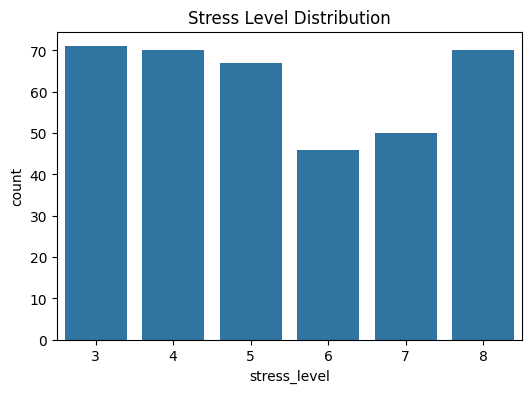

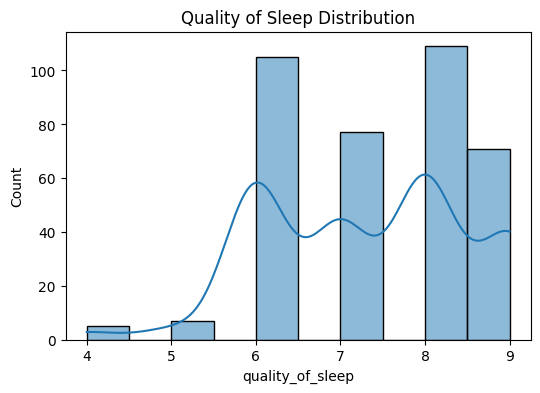

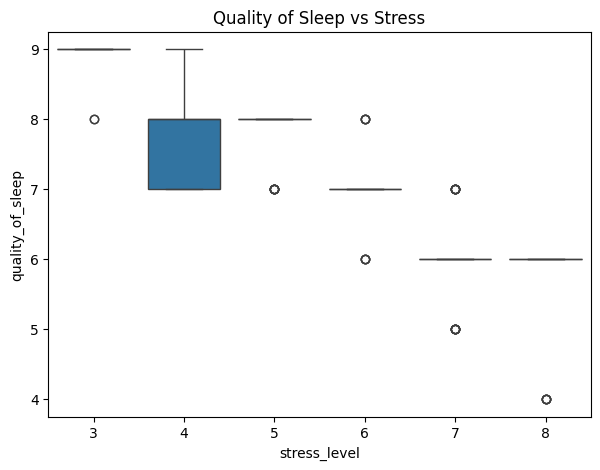

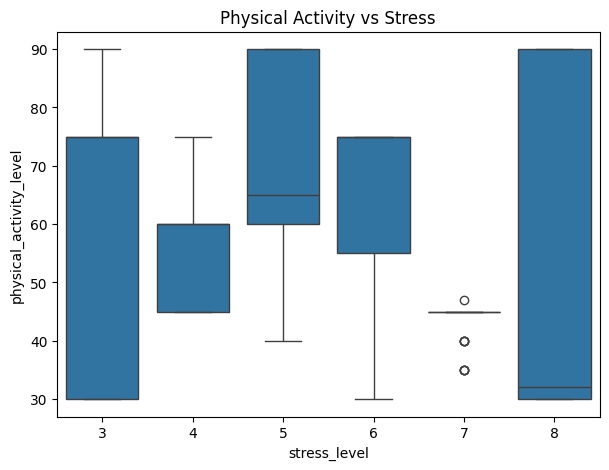

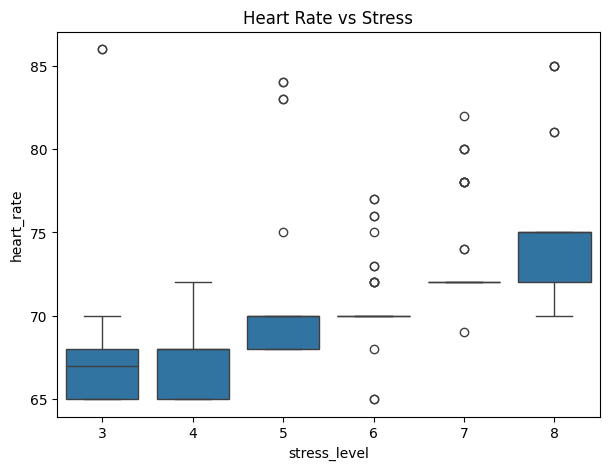

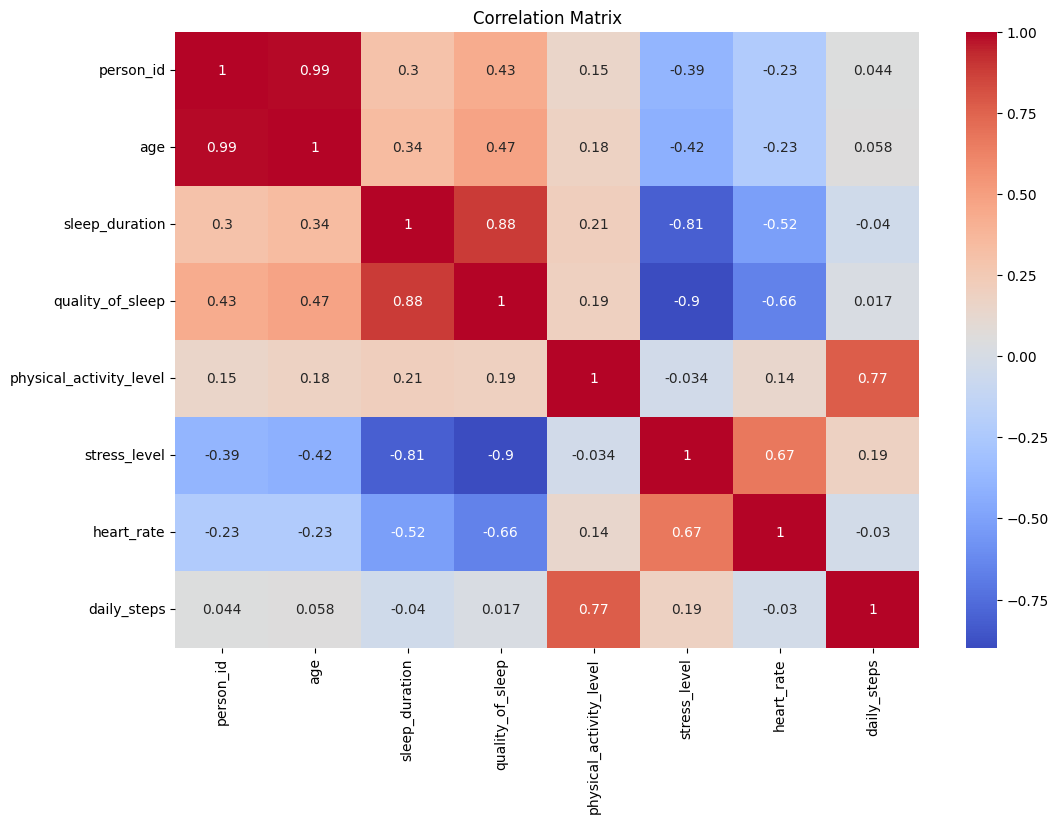

In [12]:
# ---------------------------------------------------------
# DISTRIBUSI STRESS LEVEL
# ---------------------------------------------------------

plt.figure(figsize=(6,4))

sns.countplot(
    x='stress_level',
    data=sleep_df
)

plt.title("Stress Level Distribution")
plt.show()

# ---------------------------------------------------------
# QUALITY OF SLEEP DISTRIBUTION
# ---------------------------------------------------------

plt.figure(figsize=(6,4))

sns.histplot(
    sleep_df['quality_of_sleep'],
    bins=10,
    kde=True
)

plt.title("Quality of Sleep Distribution")
plt.show()

# ---------------------------------------------------------
# QUALITY OF SLEEP VS STRESS
# ---------------------------------------------------------

plt.figure(figsize=(7,5))

sns.boxplot(
    x='stress_level',
    y='quality_of_sleep',
    data=sleep_df
)

plt.title("Quality of Sleep vs Stress")
plt.show()

# ---------------------------------------------------------
# PHYSICAL ACTIVITY VS STRESS
# ---------------------------------------------------------

plt.figure(figsize=(7,5))

sns.boxplot(
    x='stress_level',
    y='physical_activity_level',
    data=sleep_df
)

plt.title("Physical Activity vs Stress")
plt.show()

# ---------------------------------------------------------
# HEART RATE VS STRESS
# ---------------------------------------------------------

plt.figure(figsize=(7,5))

sns.boxplot(
    x='stress_level',
    y='heart_rate',
    data=sleep_df
)

plt.title("Heart Rate vs Stress")
plt.show()

# ---------------------------------------------------------
# CORRELATION MATRIX
# ---------------------------------------------------------

numeric_cols = sleep_df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

Hasil exploratory data analysis menunjukkan bahwa
faktor lifestyle dan kesehatan memiliki hubungan
yang signifikan terhadap tingkat stres.

Berdasarkan correlation matrix:

1. Quality of Sleep memiliki korelasi negatif sangat kuat
   terhadap stress level sebesar -0.90.
   Artinya, semakin baik kualitas tidur seseorang,
   maka tingkat stres cenderung menurun.

2. Sleep Duration memiliki korelasi negatif kuat
   terhadap stress level sebesar -0.81.
   Hal ini menunjukkan bahwa durasi tidur yang cukup
   berkaitan dengan tingkat stres yang lebih rendah.

3. Heart Rate memiliki korelasi positif cukup kuat
   terhadap stress level sebesar 0.67.
   Artinya, peningkatan tingkat stres cenderung diikuti
   peningkatan detak jantung.

4. Physical Activity Level memiliki korelasi negatif lemah
   terhadap stress level sebesar -0.03.
   Meskipun hubungan langsungnya tidak terlalu kuat,
   aktivitas fisik tetap berkontribusi terhadap kesehatan mental.

5. Daily Steps memiliki korelasi positif lemah
   terhadap stress level sebesar 0.19.
   Hal ini menunjukkan bahwa jumlah langkah harian
   saja belum cukup merepresentasikan kondisi stres pengguna.

Selain itu, ditemukan korelasi positif kuat sebesar 0.77
antara physical_activity_level dan daily_steps,
yang menunjukkan bahwa individu dengan aktivitas fisik tinggi
cenderung memiliki jumlah langkah harian lebih besar.

Temuan ini mendukung penggunaan kombinasi:
- questionnaire PSS,
- lifestyle data,
- dan health data

untuk membangun sistem prediksi tingkat stres.

# Data Wrangling

In [13]:
dataset = pd.DataFrame()

# Convert 'academic_pressure' in student_df to numerical for calculations
academic_pressure_mapping = {'Low': 1, 'Medium': 3, 'High': 5}
student_df['academic_pressure_numeric'] = student_df['academic_pressure'].map(academic_pressure_mapping)


dataset['gender'] = sleep_df['gender']

# =========================================================
# 15 PERTANYAAN PSS
# SKALA LIKERT 1-5
# =========================================================

# ---------------------------------------------------------
# Q1 - Sulit berkonsentrasi
# ---------------------------------------------------------

dataset['q1_focus_difficulty'] = (
    (
        student_df['academic_pressure_numeric'] * 0.6
        +
        student_df['study_hours'] * 0.4
    )
).round().clip(1,5)

# ---------------------------------------------------------
# Q2 - Overthinking
# ---------------------------------------------------------

dataset['q2_overthinking'] = (
    (
        sleep_df['stress_level'] * 0.5
        +
        student_df['academic_pressure_numeric'] * 0.5
    )
).round().clip(1,5)

# ---------------------------------------------------------
# Q3 - Merasa kewalahan
# ---------------------------------------------------------

dataset['q3_overwhelmed'] = (
    (
        sleep_df['stress_level'] * 0.6
        +
        (10 - sleep_df['quality_of_sleep']) * 0.4
    ) / 2
).round().clip(1,5)

# ---------------------------------------------------------
# Q4 - Merasa cemas
# ---------------------------------------------------------

dataset['q4_anxious'] = (
    (
        sleep_df['stress_level'] * 0.5
        +
        (sleep_df['heart_rate'] / 20) * 0.5
    )
).round().clip(1,5)

# ---------------------------------------------------------
# Q5 - Mudah gelisah
# ---------------------------------------------------------

dataset['q5_restless'] = (
    (
        (sleep_df['heart_rate'] / 20) * 0.6
        +
        sleep_df['stress_level'] * 0.4
    )
).round().clip(1,5)

# ---------------------------------------------------------
# Q6 - Merasa tertekan
# ---------------------------------------------------------

dataset['q6_depressed'] = (
    (
        student_df['academic_pressure_numeric'] * 0.5
        +
        sleep_df['stress_level'] * 0.5
    )
).round().clip(1,5)

# ---------------------------------------------------------
# Q7 - Sulit tidur
# ---------------------------------------------------------

dataset['q7_sleep_problem'] = (
    6 - (
        sleep_df['quality_of_sleep'] / 2
    )
).round().clip(1,5)

# ---------------------------------------------------------
# Q8 - Mudah lelah
# ---------------------------------------------------------

dataset['q8_fatigue'] = (
    (
        (10 - sleep_df['quality_of_sleep']) * 0.5
        +
        (6 - (sleep_df['daily_steps'] / 3000)) * 0.5
    ) / 2
).round().clip(1,5)

# ---------------------------------------------------------
# Q9 - Sakit kepala / tegang
# ---------------------------------------------------------

dataset['q9_headache_tension'] = (
    (
        sleep_df['stress_level'] * 0.5
        +
        (sleep_df['heart_rate'] / 20) * 0.5
    )
).round().clip(1,5)

# ---------------------------------------------------------
# Q10 - Sulit menyelesaikan tanggung jawab
# ---------------------------------------------------------

dataset['q10_responsibility_difficulty'] = (
    (
        student_df['study_hours'] * 0.4
        +
        student_df['academic_pressure_numeric'] * 0.6
    )
).round().clip(1,5)

# ---------------------------------------------------------
# Q11 - Mudah marah
# ---------------------------------------------------------

dataset['q11_irritable'] = (
    sleep_df['stress_level'] / 2
).round().clip(1,5)

# ---------------------------------------------------------
# Q12 - Menghindari sosial
# ---------------------------------------------------------

dataset['q12_social_withdrawal'] = (
    student_df['screen_time_hours'] / 2
).round().clip(1,5)

# ---------------------------------------------------------
# Q13 - Bisa mengendalikan stres
# POSITIVE QUESTION
# ---------------------------------------------------------

dataset['q13_control_stress'] = (
    sleep_df['physical_activity_level'] / 20
).round().clip(1,5)

# ---------------------------------------------------------
# Q14 - Bisa menenangkan diri
# POSITIVE QUESTION
# ---------------------------------------------------------

dataset['q14_calm_self'] = (
    (
        (sleep_df['quality_of_sleep'] / 2) * 0.5
        +
        (sleep_df['physical_activity_level'] / 20) * 0.5
    )
).round().clip(1,5)

# ---------------------------------------------------------
# Q15 - Mampu menghadapi masalah
# POSITIVE QUESTION
# ---------------------------------------------------------

dataset['q15_handle_problem'] = (
    (
        (sleep_df['quality_of_sleep'] / 2) * 0.3
        +
        (sleep_df['physical_activity_level'] / 20) * 0.3
        +
        (5 - sleep_df['stress_level'] / 2) * 0.4
    )
).round().clip(1,5)

Pada tahap ini dilakukan proses **feature engineering** untuk membentuk dataset baru yang merepresentasikan tingkat stres psikologis berdasarkan 15 indikator yang mengacu pada konsep **Perceived Stress Scale (PSS)**. Setiap indikator dihitung menggunakan kombinasi variabel yang tersedia pada Sleep Dataset dan Student Dataset, seperti tingkat stres, kualitas tidur, aktivitas fisik, tekanan akademik, jam belajar, detak jantung, jumlah langkah harian, dan durasi penggunaan layar. Variabel kategorikal `academic_pressure` terlebih dahulu dikonversi menjadi skala numerik agar dapat digunakan dalam proses perhitungan. Selanjutnya, setiap indikator diberikan skor pada rentang 1–5 melalui pembobotan yang disesuaikan dengan hubungan logis antara faktor gaya hidup, kesehatan, dan kondisi psikologis. Hasil dari proses ini adalah dataset yang berisi 15 variabel indikator stres yang dapat digunakan untuk mengukur, menganalisis, dan memprediksi tingkat stres berdasarkan pola gaya hidup dan kondisi kesehatan individu.


## Reverse Scoring

In [14]:
dataset['q13_control_stress'] = (
    6 - dataset['q13_control_stress']
)

dataset['q14_calm_self'] = (
    6 - dataset['q14_calm_self']
)

dataset['q15_handle_problem'] = (
    6 - dataset['q15_handle_problem']
)

Kode tersebut melakukan proses **reverse scoring** pada pertanyaan ke-13, ke-14, dan ke-15 yang merupakan **pertanyaan positif (positive items)** dalam skala stres. Pada pertanyaan positif, skor yang tinggi menunjukkan kemampuan yang lebih baik dalam mengendalikan stres, menenangkan diri, dan menghadapi masalah, sehingga arah penilaiannya berlawanan dengan pertanyaan lainnya yang mengukur tingkat stres secara langsung. Oleh karena itu, dilakukan transformasi menggunakan rumus `6 - skor` agar seluruh indikator memiliki arah interpretasi yang sama, yaitu semakin tinggi skor maka semakin tinggi tingkat stres yang dirasakan. Proses ini penting untuk menjaga konsistensi pengukuran sebelum dilakukan perhitungan skor stres total maupun analisis lanjutan.


# Total PSS Score

In [15]:
question_cols = [
    'q1_focus_difficulty',
    'q2_overthinking',
    'q3_overwhelmed',
    'q4_anxious',
    'q5_restless',
    'q6_depressed',
    'q7_sleep_problem',
    'q8_fatigue',
    'q9_headache_tension',
    'q10_responsibility_difficulty',
    'q11_irritable',
    'q12_social_withdrawal',
    'q13_control_stress',
    'q14_calm_self',
    'q15_handle_problem'
]

dataset['pss_total_score'] = (
    dataset[question_cols]
    .sum(axis=1)
)

**Interpretasi:**

Kode tersebut digunakan untuk menghitung **skor total Perceived Stress Scale (PSS)** dengan menjumlahkan seluruh skor dari 15 indikator pertanyaan yang telah dibentuk sebelumnya. Daftar pertanyaan disimpan dalam variabel `question_cols`, kemudian fungsi `.sum(axis=1)` digunakan untuk menjumlahkan skor setiap responden pada seluruh pertanyaan dalam satu baris data. Hasil penjumlahan tersebut disimpan ke dalam variabel baru bernama `pss_total_score`, yang merepresentasikan tingkat stres keseluruhan masing-masing individu. Semakin tinggi nilai `pss_total_score`, maka semakin tinggi tingkat stres yang dialami, sedangkan nilai yang lebih rendah menunjukkan tingkat stres yang relatif lebih rendah. Skor total ini selanjutnya dapat digunakan sebagai variabel utama dalam analisis deskriptif, korelasi, maupun pemodelan prediktif terkait faktor-faktor yang memengaruhi stres.


# Target Labeling

In [16]:
def stress_category(score):

    if score <= 35:
        return "Low"

    elif score <= 55:
        return "Medium"

    else:
        return "High"

dataset['stress_level'] = (
    dataset['pss_total_score']
    .apply(stress_category)
)

Kode tersebut digunakan untuk mengelompokkan skor total PSS (`pss_total_score`) ke dalam tiga kategori tingkat stres, yaitu **Low**, **Medium**, dan **High**. Fungsi `stress_category()` menetapkan bahwa responden dengan skor total ≤ 35 dikategorikan memiliki tingkat stres rendah (*Low*), skor antara 36–55 dikategorikan sebagai tingkat stres sedang (*Medium*), dan skor di atas 55 dikategorikan sebagai tingkat stres tinggi (*High*). Selanjutnya, fungsi `.apply()` digunakan untuk menerapkan aturan klasifikasi tersebut pada setiap nilai `pss_total_score`, sehingga menghasilkan variabel baru bernama `stress_level`. Variabel ini memudahkan interpretasi hasil analisis karena tingkat stres tidak hanya ditampilkan dalam bentuk skor numerik, tetapi juga dalam kategori yang lebih mudah dipahami dan dibandingkan.


# Additional Features

In [17]:
dataset['quality_of_sleep'] = (
    sleep_df['quality_of_sleep']
)

dataset['physical_activity_level'] = (
    sleep_df['physical_activity_level']
)

dataset['heart_rate'] = (
    sleep_df['heart_rate']
)

dataset['daily_steps'] = (
    sleep_df['daily_steps']
)

dataset['screen_time_hours'] = (
    student_df['screen_time_hours']
)

dataset['study_hours'] = (
    student_df['study_hours']
)

dataset['daily_pressure'] = (
    student_df['academic_pressure']
)

dataset['bmi_category'] = (
    sleep_df['bmi_category']
)

Sintaks tersebut digunakan untuk menambahkan variabel-variabel penting dari **Sleep Dataset** dan **Student Dataset** ke dalam dataset utama yang telah berisi skor dan kategori tingkat stres. Variabel yang ditambahkan meliputi **quality_of_sleep**, **physical_activity_level**, **heart_rate**, **daily_steps**, **screen_time_hours**, **study_hours**, **daily_pressure**, dan **bmi_category**. Tujuan penggabungan ini adalah untuk menyediakan variabel independen yang relevan dengan kondisi kesehatan dan gaya hidup individu sehingga dapat digunakan dalam analisis lebih lanjut, seperti analisis hubungan antarvariabel, identifikasi faktor yang memengaruhi tingkat stres, serta pembangunan model prediksi tingkat stres berdasarkan faktor kesehatan fisik dan kebiasaan sehari-hari. Dengan demikian, dataset yang dihasilkan menjadi lebih komprehensif karena mengintegrasikan informasi psikologis, kesehatan, dan gaya hidup dalam satu struktur data.


# Final Dataset

In [18]:
print("""
FINAL DATASET
""")

print(dataset.head())

print("\nDataset Shape:")
print(dataset.shape)

print("\nDataset Info:")
print(dataset.info())


FINAL DATASET

  gender  q1_focus_difficulty  q2_overthinking  q3_overwhelmed  q4_anxious  \
0   Male                  5.0              5.0             3.0         5.0   
1   Male                  2.0              4.0             3.0         5.0   
2   Male                  4.0              5.0             3.0         5.0   
3   Male                  5.0              5.0             4.0         5.0   
4   Male                  5.0              5.0             4.0         5.0   

   q5_restless  q6_depressed  q7_sleep_problem  q8_fatigue  \
0          5.0           5.0               3.0         2.0   
1          5.0           4.0               3.0         2.0   
2          5.0           5.0               3.0         2.0   
3          5.0           5.0               4.0         3.0   
4          5.0           5.0               4.0         3.0   

   q9_headache_tension  q10_responsibility_difficulty  q11_irritable  \
0                  5.0                            5.0            3.0  

Hasil akhir menunjukkan bahwa dataset yang telah dibangun terdiri dari **374 observasi** dan **26 variabel** yang mengintegrasikan indikator stres psikologis, faktor kesehatan fisik, serta faktor gaya hidup. Dataset ini mencakup 15 indikator stres berbasis konsep Perceived Stress Scale (PSS), skor total stres (`pss_total_score`), kategori tingkat stres (`stress_level`), serta variabel pendukung seperti kualitas tidur, tingkat aktivitas fisik, detak jantung, jumlah langkah harian, durasi penggunaan layar, jam belajar, tekanan akademik, dan kategori BMI. Berdasarkan informasi struktur data, seluruh variabel memiliki **374 nilai non-null**, sehingga tidak terdapat missing value pada dataset final. Tipe data yang digunakan terdiri atas **18 variabel numerik bertipe float, 4 variabel numerik bertipe interger, dan 4 variabel kategorikal bertipe object**, yang menunjukkan bahwa dataset telah siap digunakan untuk analisis statistik, eksplorasi data, pengujian hubungan antarvariabel, maupun pembangunan model prediksi tingkat stres. Dengan menggabungkan aspek psikologis, kesehatan, dan gaya hidup dalam satu dataset, analisis yang dilakukan diharapkan dapat memberikan pemahaman yang lebih komprehensif mengenai faktor-faktor yang memengaruhi tingkat stres individu.


# EDA Final

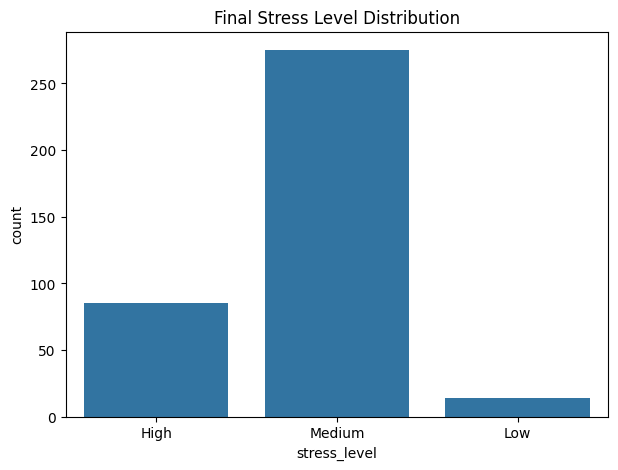

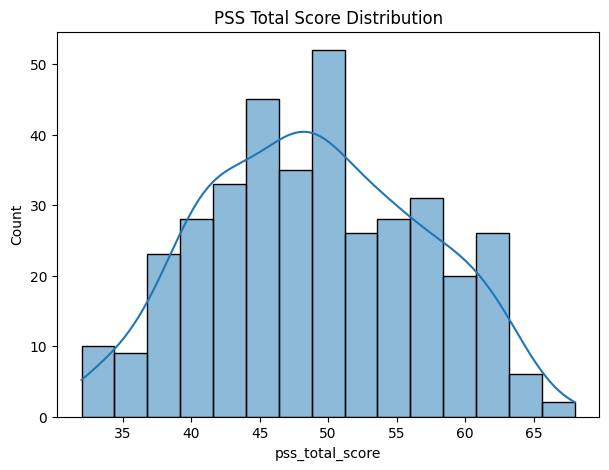

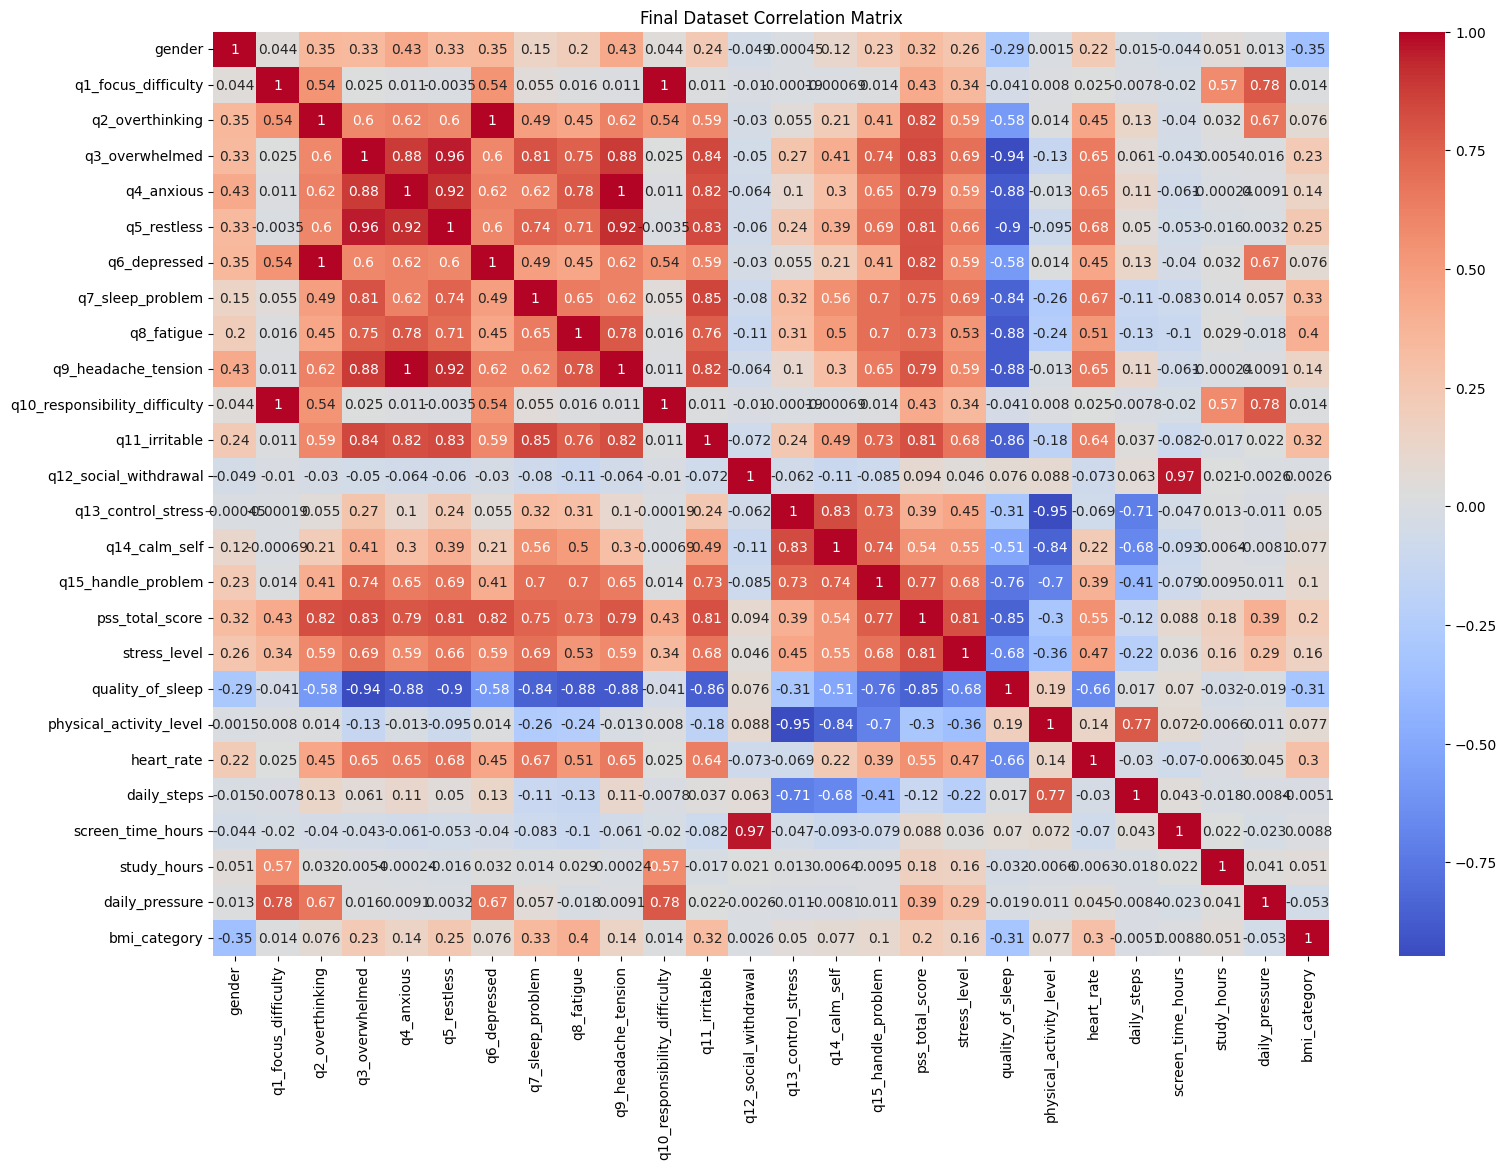

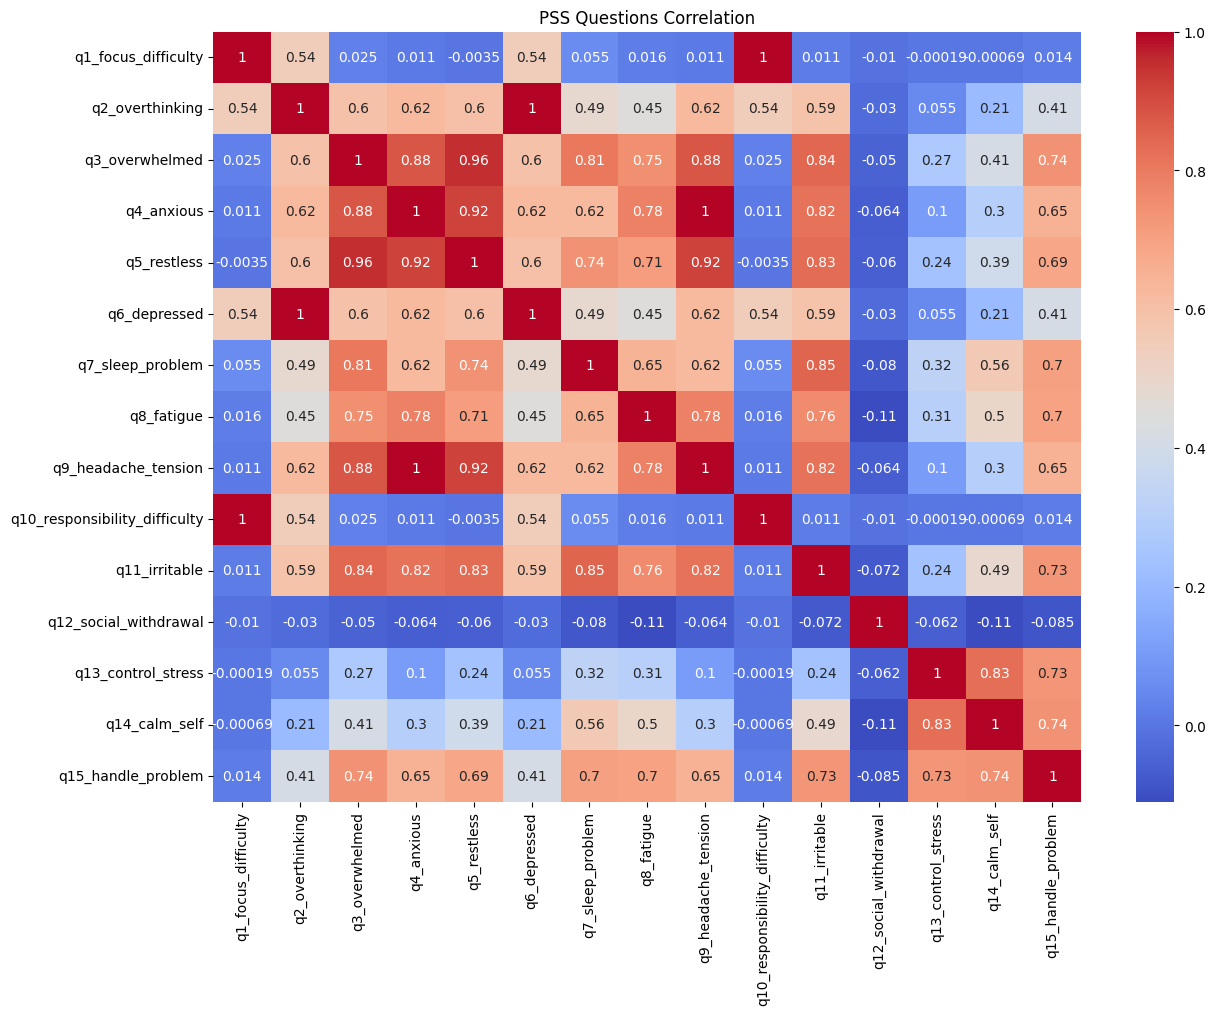

In [19]:
# ---------------------------------------------------------
# FINAL STRESS DISTRIBUTION
# ---------------------------------------------------------

plt.figure(figsize=(7,5))

sns.countplot(
    x='stress_level',
    data=dataset
)

plt.title("Final Stress Level Distribution")
plt.show()

# ---------------------------------------------------------
# PSS TOTAL SCORE DISTRIBUTION
# ---------------------------------------------------------

plt.figure(figsize=(7,5))

sns.histplot(
    dataset['pss_total_score'],
    bins=15,
    kde=True
)

plt.title("PSS Total Score Distribution")
plt.show()

# ---------------------------------------------------------
# FINAL CORRELATION MATRIX
# ---------------------------------------------------------

# Prepare data for correlation matrix: encode categorical features
encoded_dataset = dataset.copy()

# Label encode 'gender'
le = LabelEncoder()
encoded_dataset['gender'] = le.fit_transform(encoded_dataset['gender'])

# Map 'stress_level' to numerical values
stress_level_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
encoded_dataset['stress_level'] = encoded_dataset['stress_level'].map(stress_level_mapping)

# Map 'daily_pressure' to numerical values
daily_pressure_mapping = {'Low': 1, 'Medium': 3, 'High': 5} # Using the same mapping as academic_pressure_numeric
encoded_dataset['daily_pressure'] = encoded_dataset['daily_pressure'].map(daily_pressure_mapping)

# Label encode 'bmi_category'
encoded_dataset['bmi_category'] = le.fit_transform(encoded_dataset['bmi_category'])

plt.figure(figsize=(18,12))

sns.heatmap(
    encoded_dataset.corr(),
    annot=True, # Added annot=True for better readability
    cmap='coolwarm'
)

plt.title("Final Dataset Correlation Matrix")
plt.show()

# ---------------------------------------------------------
# PSS QUESTION CORRELATION
# ---------------------------------------------------------

plt.figure(figsize=(14,10))

sns.heatmap(
    dataset[question_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("PSS Questions Correlation")
plt.show()


Mayoritas individu berada pada kategori Medium Stress dengan persentase sekitar 78.3% dari total dataset.

Kategori High Stress masih cukup signifikan yaitu sekitar 20.3%, menunjukkan bahwa sebagian individu mengalami tekanan psikologis yang tinggi.

Namun kategori Low Stress hanya sekitar 1.4%, sehingga dataset masih mengalami class imbalance.

- Sebagian besar individu memiliki skor PSS pada kategori sedang hingga tinggi.

- Kualitas tidur memiliki hubungan negatif sedang terhadap tingkat stres.
Semakin baik kualitas tidur,
maka tingkat stres cenderung menurun. Nilai korelasi sebesar -0.52 menunjukkan bahwa kualitas tidur merupakan salah satu fitur penting dalam prediksi stres.

- Heart rate memiliki hubungan positif sedang terhadap tingkat stres.Peningkatan stres cenderung diikuti peningkatan denyut jantung. Hal ini mendukung teori physiological stress response.

- Aktivitas fisik memiliki hubungan negatif lemah terhadap tingkat stres. Meskipun korelasinya tidak terlalu kuat, hasil ini menunjukkan bahwa:
individu yang lebih aktif secara fisik
cenderung memiliki tingkat stres lebih rendah.

- Jumlah langkah harian memiliki hubungan positif kuat terhadap physical activity level. Individu dengan aktivitas fisik tinggi
cenderung memiliki jumlah langkah harian lebih besar. Korelasi sebesar 0.77 menunjukkan konsistensi logis pada dataset.

- Individu yang merasa kewalahan cenderung juga mengalami kegelisahan Korelasi sangat kuat sebesar 0.96 menunjukkan bahwa kedua gejala stres tersebut saling berkaitan secara psikologis.

- Kecemasan memiliki hubungan sangat kuat terhadap kegelisahan.

- Gangguan tidur memiliki hubungan kuat terhadap irritability atau emosi negatif.

- Kemampuan mengendalikan stres memiliki hubungan kuat terhadap kemampuan menenangkan diri.

- Kemampuan menghadapi masalah memiliki hubungan negatif kuat terhadap perasaan kewalahan.

In [20]:
le_gender = LabelEncoder()
le_bmi = LabelEncoder()
le_stress = LabelEncoder()

dataset['gender'] = (
    le_gender.fit_transform(dataset['gender'])
)

dataset['bmi_category'] = (
    le_bmi.fit_transform(dataset['bmi_category'])
)

dataset['stress_level'] = (
    le_stress.fit_transform(dataset['stress_level'])
)

Sintaks tersebut melakukan proses **encoding** terhadap variabel kategorikal menggunakan metode **Label Encoding**. Tujuannya adalah mengubah data berbentuk teks (*categorical data*) menjadi nilai numerik agar dapat digunakan dalam analisis statistik maupun algoritma machine learning yang umumnya hanya dapat memproses data numerik. Pada proses ini, variabel **gender**, **bmi_category**, dan **stress_level** dikonversi menjadi representasi angka menggunakan objek `LabelEncoder()` yang berbeda untuk setiap variabel. Sebagai contoh, kategori seperti *Male* dan *Female* akan diubah menjadi angka (misalnya 0 dan 1), sedangkan kategori pada BMI dan tingkat stres juga akan diberikan kode numerik sesuai jumlah kategorinya. Setelah proses encoding selesai, dataset menjadi lebih siap untuk digunakan pada tahap pemodelan, pengujian hubungan antarvariabel, maupun analisis prediktif.

# Data for ML

In [21]:
X = dataset.drop(
    'stress_level',
    axis=1
)

y = dataset['stress_level']

# =========================================================
# TRAIN TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("""
=========================================================
DATA SPLIT
=========================================================
""")

print("X Train :", X_train.shape)
print("X Test  :", X_test.shape)


DATA SPLIT

X Train : (299, 25)
X Test  : (75, 25)


Variabel stress_level dipisahkan sebagai target variable (y) yang akan diprediksi, sedangkan seluruh variabel lainnya digunakan sebagai fitur atau variabel independen (X) melalui fungsi drop(). Selanjutnya, dataset dibagi menjadi data latih (training set) dan data uji (testing set) menggunakan fungsi train_test_split() dengan proporsi 80% data latih dan 20% data uji. Parameter random_state=42 digunakan agar hasil pembagian data dapat direproduksi secara konsisten, sedangkan stratify=y memastikan distribusi kategori tingkat stres pada data latih dan data uji tetap seimbang sesuai distribusi pada dataset asli. Proses ini penting untuk mengevaluasi kinerja model secara objektif, di mana model akan dilatih menggunakan data latih dan diuji menggunakan data yang belum pernah dilihat sebelumnya pada data uji.

# Data Dictionary

In [22]:
data_dictionary = pd.DataFrame({
    "Column": dataset.columns,
    "Description": [
        "Gender pengguna",
        "Kesulitan berkonsentrasi",
        "Overthinking",
        "Merasa kewalahan",
        "Merasa cemas",
        "Mudah gelisah",
        "Merasa tertekan",
        "Sulit tidur",
        "Mudah lelah",
        "Sakit kepala atau tegang",
        "Kesulitan menyelesaikan tanggung jawab",
        "Mudah marah",
        "Menghindari sosial",
        "Mengendalikan stres",
        "Menenangkan diri",
        "Menghadapi masalah",
        "Total skor PSS",
        "Target tingkat stres",
        "Kualitas tidur",
        "Aktivitas fisik",
        "Heart rate",
        "Jumlah langkah harian",
        "Durasi screen time",
        "Intensitas aktivitas",
        "Tekanan aktivitas harian",
        "Kategori BMI"
    ]
})

print("""
DATA DICTIONARY
""")

print(data_dictionary)


DATA DICTIONARY

                           Column                             Description
0                          gender                         Gender pengguna
1             q1_focus_difficulty                Kesulitan berkonsentrasi
2                 q2_overthinking                            Overthinking
3                  q3_overwhelmed                        Merasa kewalahan
4                      q4_anxious                            Merasa cemas
5                     q5_restless                           Mudah gelisah
6                    q6_depressed                         Merasa tertekan
7                q7_sleep_problem                             Sulit tidur
8                      q8_fatigue                             Mudah lelah
9             q9_headache_tension                Sakit kepala atau tegang
10  q10_responsibility_difficulty  Kesulitan menyelesaikan tanggung jawab
11                  q11_irritable                             Mudah marah
12          q12_soci

In [25]:
data_dictionary.to_csv("data_dictionary.csv", index=False)

Data dictionary di atas menjelaskan setiap variabel yang terdapat pada dataset final beserta maknanya. Dataset terdiri dari variabel demografis (`gender`), indikator stres berbasis Perceived Stress Scale (PSS) yang direpresentasikan melalui 15 pertanyaan (`q1` hingga `q15`), skor total stres (`pss_total_score`), serta kategori tingkat stres (`stress_level`) sebagai variabel target. Selain itu, dataset juga memuat berbagai faktor kesehatan dan gaya hidup seperti kualitas tidur, aktivitas fisik, detak jantung, jumlah langkah harian, durasi penggunaan layar (*screen time*), intensitas aktivitas atau jam belajar, tekanan aktivitas harian, dan kategori BMI. Keberadaan variabel-variabel tersebut memungkinkan analisis yang lebih komprehensif mengenai hubungan antara kondisi kesehatan, pola hidup, dan tingkat stres individu, serta mendukung pembangunan model prediksi tingkat stres berdasarkan karakteristik responden.


# Export Dataset

In [23]:
dataset.to_csv(
    "final_stress_dataset.csv",
    index=False
)

print("""
=========================================================
EXPORT SUCCESS
=========================================================

Dataset berhasil disimpan:
final_stress_dataset.csv

=========================================================
""")


EXPORT SUCCESS

Dataset berhasil disimpan:
final_stress_dataset.csv




In [24]:
print(dataset.head())

   gender  q1_focus_difficulty  q2_overthinking  q3_overwhelmed  q4_anxious  \
0       1                  5.0              5.0             3.0         5.0   
1       1                  2.0              4.0             3.0         5.0   
2       1                  4.0              5.0             3.0         5.0   
3       1                  5.0              5.0             4.0         5.0   
4       1                  5.0              5.0             4.0         5.0   

   q5_restless  q6_depressed  q7_sleep_problem  q8_fatigue  \
0          5.0           5.0               3.0         2.0   
1          5.0           4.0               3.0         2.0   
2          5.0           5.0               3.0         2.0   
3          5.0           5.0               4.0         3.0   
4          5.0           5.0               4.0         3.0   

   q9_headache_tension  q10_responsibility_difficulty  q11_irritable  \
0                  5.0                            5.0            3.0   
1       